In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set Seaborn style
sns.set_theme(style="whitegrid")  # Using seaborn's whitegrid style
sns.set_palette("husl")  # Setting color palette

# Load the preprocessed dataset with engineered features
df = pd.read_csv('spotify_emeritus.csv')

# Remove unnecessary columns and handle missing values
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df = df.dropna()


In [13]:
# Create engineered features
from sklearn.preprocessing import LabelEncoder

# Composite features
df['energy_loudness_composite'] = (df['energy'] * df['loudness'].clip(lower=0)).fillna(0)
df['energy_acousticness_ratio'] = df['energy'] / (df['acousticness'] + 0.01)

# Categorical encoding using LabelEncoder
# Genre encoding
le_genre = LabelEncoder()
df['genre_label_encoded'] = le_genre.fit_transform(df['track_genre'])

# Artist encoding
le_artist = LabelEncoder()
df['artist_label_encoded'] = le_artist.fit_transform(df['artists'])

# Album encoding
le_album = LabelEncoder()
df['album_label_encoded'] = le_album.fit_transform(df['album_name'])

# Musical features
df['mode'] = df['mode']  # Already binary (0 for minor, 1 for major)
df['key'] = df['key']  # Already numeric
df['time_signature'] = df['time_signature']  # Already numeric
df['is_explicit'] = df['explicit'].astype(int)  # Convert boolean to int

# Interaction features
df['danceability_energy'] = df['danceability'] * df['energy']
df['valence_energy'] = df['valence'] * df['energy']
df['loudness_danceability'] = df['loudness'] * df['danceability']
df['key_mode_interaction'] = df['key'] * df['mode']

# Duration transformation
df['duration_minutes'] = df['duration_ms'] / 60000
df['duration_minutes_log'] = np.log1p(df['duration_minutes'])

# Define features for modeling
regression_features = [
    # Original audio features
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    
    # Musical theory features
    'key', 'mode', 'time_signature',
    
    # Metadata features
    'is_explicit', 'genre_label_encoded', 'artist_label_encoded', 'album_label_encoded',
    
    # Engineered features
    'energy_loudness_composite', 'energy_acousticness_ratio',
    'danceability_energy', 'valence_energy', 'loudness_danceability',
    'duration_minutes_log', 'key_mode_interaction'
]

# Create feature matrix X and target variable y
X = df[regression_features]
y = df['popularity']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
# Initialize models with tuned parameters for larger feature set
models = {
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=40,  # Increased from 20
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=40,  # Increased from 20
        max_depth=7,
        learning_rate=0.1,
        random_state=42
    )
}

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Initialize lists to store fold scores
    fold_rmse = []
    
    # Perform manual k-fold cross-validation
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split data for this fold
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train model
        model.fit(X_fold_train, y_fold_train)
        
        # Make predictions
        y_fold_pred = model.predict(X_fold_val)
        
        # Calculate RMSE for this fold
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, y_fold_pred)))
        
    # Calculate cross-validation statistics
    cv_rmse_mean = np.mean(fold_rmse)
    cv_rmse_std = np.std(fold_rmse)
    
    # Train model on full training set
    model.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std': cv_rmse_std,
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }
    
    print(f"{name} Results:")
    print(f"Cross-validation RMSE: {cv_rmse_mean:.2f} (+/- {cv_rmse_std*2:.2f})")
    print(f"Test RMSE: {rmse:.2f}")
    print(f"Test MAE: {mae:.2f}")
    print(f"Test R²: {r2:.3f}")



Training Decision Tree...
Decision Tree Results:
Cross-validation RMSE: 20.21 (+/- 0.09)
Test RMSE: 20.25
Test MAE: 15.97
Test R²: 0.173

Training Random Forest...
Random Forest Results:
Cross-validation RMSE: 17.22 (+/- 0.21)
Test RMSE: 16.98
Test MAE: 13.18
Test R²: 0.419

Training XGBoost...
XGBoost Results:
Cross-validation RMSE: 18.23 (+/- 0.12)
Test RMSE: 18.16
Test MAE: 14.21
Test R²: 0.335


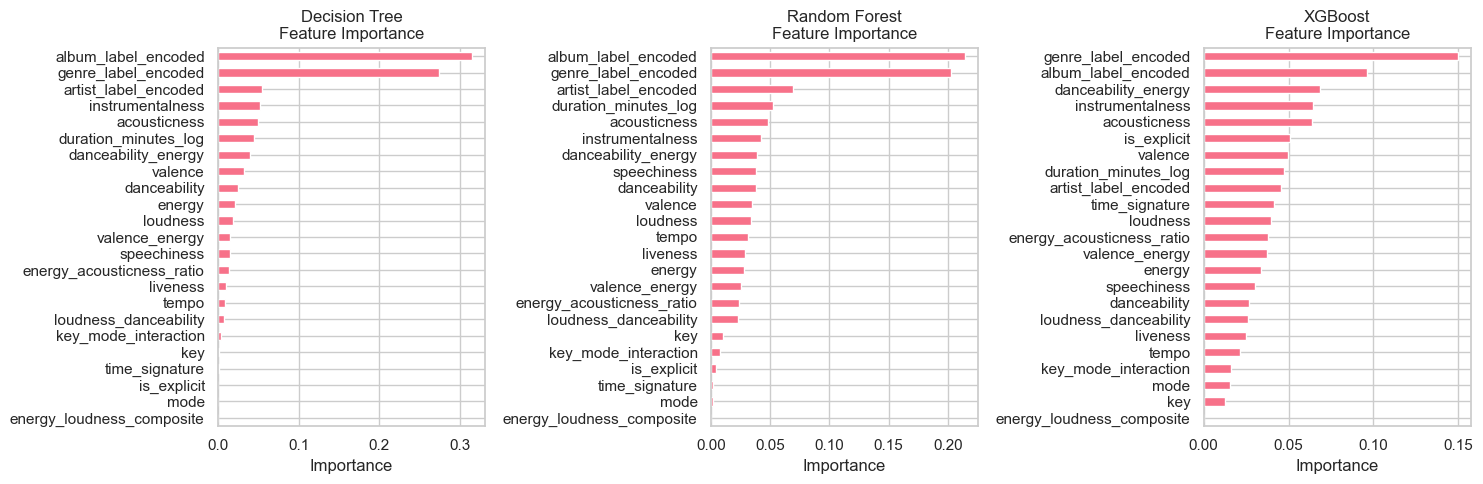


Top 5 Most Important Features by Model:

Decision Tree:
album_label_encoded     0.314891
genre_label_encoded     0.273881
artist_label_encoded    0.054001
instrumentalness        0.051824
acousticness            0.049119
dtype: float64

Random Forest:
album_label_encoded     0.214351
genre_label_encoded     0.202422
artist_label_encoded    0.069199
duration_minutes_log    0.052132
acousticness            0.048375
dtype: float64

XGBoost:
genre_label_encoded    0.149769
album_label_encoded    0.096369
danceability_energy    0.068619
instrumentalness       0.064477
acousticness           0.063908
dtype: float32


In [15]:
# Create feature importance plots for each model
plt.figure(figsize=(15, 5))

# Plot for Decision Tree
plt.subplot(1, 3, 1)
importances_dt = pd.Series(models['Decision Tree'].feature_importances_, index=regression_features)
importances_dt.sort_values(ascending=True).plot(kind='barh')
plt.title('Decision Tree\nFeature Importance')
plt.xlabel('Importance')

# Plot for Random Forest
plt.subplot(1, 3, 2)
importances_rf = pd.Series(models['Random Forest'].feature_importances_, index=regression_features)
importances_rf.sort_values(ascending=True).plot(kind='barh')
plt.title('Random Forest\nFeature Importance')
plt.xlabel('Importance')

# Plot for XGBoost
plt.subplot(1, 3, 3)
importances_xgb = pd.Series(models['XGBoost'].feature_importances_, index=regression_features)
importances_xgb.sort_values(ascending=True).plot(kind='barh')
plt.title('XGBoost\nFeature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# Print feature importance summary
print("\nTop 5 Most Important Features by Model:")
for name in models.keys():
    importances = pd.Series(models[name].feature_importances_, index=regression_features)
    print(f"\n{name}:")
    print(importances.sort_values(ascending=False).head())


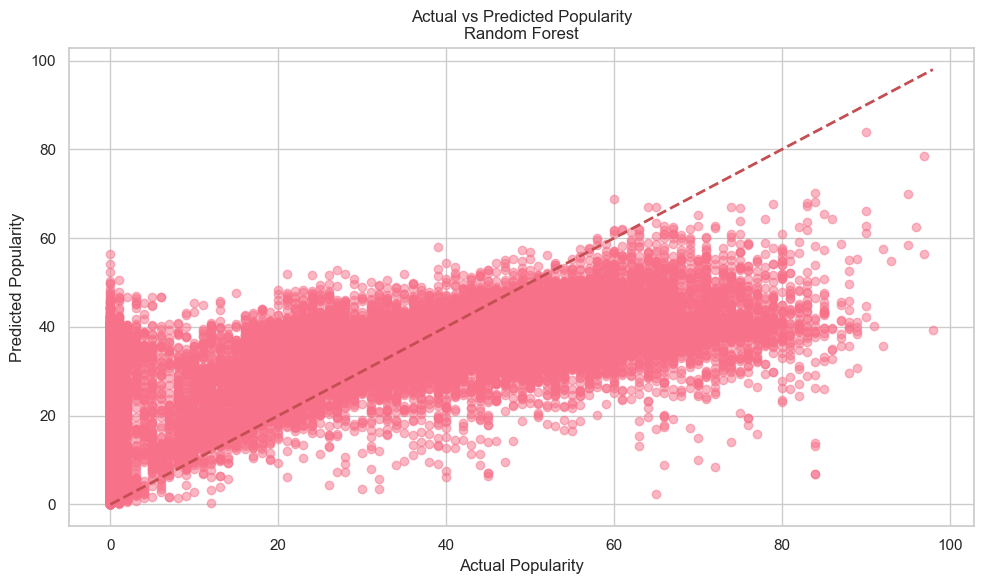

<Figure size 1200x600 with 0 Axes>

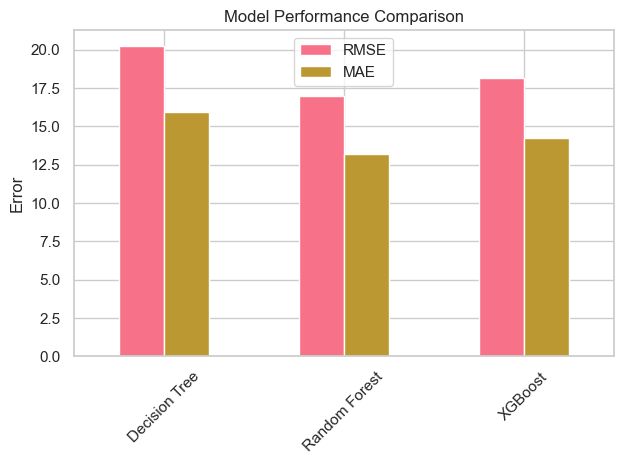


Detailed Model Comparison:
                 RMSE     MAE     R²
Decision Tree  20.253  15.965  0.173
Random Forest  16.976  13.177  0.419
XGBoost        18.163  14.215  0.335


In [16]:
# Compare actual vs predicted values for the best model
best_model_name = min(results, key=lambda x: results[x]['test_rmse'])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title(f'Actual vs Predicted Popularity\n{best_model_name}')
plt.tight_layout()
plt.show()

# Create comparison bar plot of model performance
model_comparison = pd.DataFrame({
    'RMSE': [results[model]['test_rmse'] for model in results],
    'MAE': [results[model]['test_mae'] for model in results],
    'R²': [results[model]['test_r2'] for model in results]
}, index=results.keys())

# Plot performance metrics
plt.figure(figsize=(12, 6))
model_comparison[['RMSE', 'MAE']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nDetailed Model Comparison:")
print(model_comparison.round(3))
